<a href="https://colab.research.google.com/github/nawroz-m/ML_learning/blob/supervised/es6_CNN_transfer_learning_assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**!ASSIGNMENT!**

*Transfer learning*
1. Finetune [AlexNet](https://pytorch.org/vision/main/models/generated/torchvision.models.alexnet.html) on the SimplicityDB, the dataset used during the last lecture. Fine-tune the network and compare how well it performs on the test-set compared to the model developed last time.

In [7]:
import torch
import glob  # Import library for finding all files matching a pattern
from PIL import Image  # Import library for image processing
import numpy as np  # Import library for numerical operations (not used here)
import os  # Import library for operating system functionalities
import tqdm

import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, utils
import torchvision
import pandas as pd
import scipy
import collections

import pickle

from google.colab import drive

In [2]:
device = 'cuda:0' if torch.cuda.is_available() else 'cpu'
device

'cuda:0'

Data preparation

In [8]:
drive.flush_and_unmount()
drive.mount("/content/drive")

Mounted at /content/drive


In [ ]:
#download images
# unzip the dataset
!unzip /content/drive/MyDrive/Supervised/CNN/SimplicityDB.zip

Remove grayscale images

In [10]:


# Define a path pattern to search for all jpg images within subdirectories of "/content/imdb_crop"
image_path_pattern = "SimplicityDB/*/*.jpg"

# Find all image file paths matching the pattern
image_paths = glob.glob(image_path_pattern)

# Iterate through each image path
for image_path in tqdm.tqdm(image_paths):
  # Open the image using Pillow's Image class
  image = Image.open(image_path)

  # Get the number of color channels in the image (e.g., RGB has 3 channels)
  num_channels = len(image.getbands())

  # Check if the image has a different number of channels than expected (likely grayscale or unsupported format)
  if num_channels != 3:
    # If not 3 channels, remove the image file
    os.remove(image_path)
    # print(f"Removed {image_path} (not RGB format)")  # Print statement to show removed files


0it [00:00, ?it/s]


Build the train/val/test dataloaders

In [49]:
# Define data transformations (augmentations for training and normalization)
transform_train = transforms.Compose([
    transforms.Resize((256, 256)),  # Resize images to 256x256
    transforms.RandomHorizontalFlip(p=0.5),  # Randomly flip images horizontally for training augmentation
    transforms.ToTensor(),  # Convert PIL images to PyTorch tensors
    transforms.Normalize(  # Normalize pixel values based on ImageNet statistics
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

transform_val = transforms.Compose([
    transforms.Resize((256, 256)),  # Resize images to 256x256 (consistent with training)
    transforms.ToTensor(),  # Convert PIL images to PyTorch tensors
    transforms.Normalize(  # Normalize pixel values using the same statistics
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# Set batch size
bs = 32


# loade full training data
full_dataset = torchvision.datasets.ImageFolder('SimplicityDB/train')
# Split into train (80%) and val (20%)
train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size

train_subset, val_subset = torch.utils.data.random_split(
    full_dataset, [train_size, val_size]
)
# Apply DIFFERENT transforms
train_subset.dataset.transform = transform_train
val_subset.dataset.transform = transform_val


# get all the training and testing Image folder
train_data = torchvision.datasets.ImageFolder('SimplicityDB/train', transform=transform_train)
val_data = torchvision.datasets.ImageFolder('SimplicityDB/train', transform=transform_val)
test_data = torchvision.datasets.ImageFolder('SimplicityDB/test', transform=transform_val)

# load the training & testing datasets
train_loader = torch.utils.data.DataLoader(train_data, batch_size=bs, shuffle=True, drop_last=True)
val_loader = torch.utils.data.DataLoader(val_data, batch_size=bs, shuffle=True, drop_last=False)
test_loader = torch.utils.data.DataLoader(test_data, batch_size=bs, shuffle=True, drop_last=False)

classes = ['People', 'Beaches', 'Buildings', 'Buses',
           'Dinosarus', 'Elephants', 'Flowers', 'Horses', "Mountains", "Food"]

# Print dataset and dataloader lengths (number of samples and batches)
print(f"Number of training samples: {len(train_loader) * bs}")
print(f"Number of val samples: {len(val_loader)}")

print(f"Number of test samples: {len(test_loader)}")
print(f"classes: {train_data.classes}")

Number of training samples: 672
Number of val samples: 22
Number of test samples: 10
classes: ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9']


In [16]:
# Orignal alexnet model structure
torchvision.models.alexnet(weights='IMAGENET1K_V1')

Downloading: "https://download.pytorch.org/models/alexnet-owt-7be5be79.pth" to /root/.cache/torch/hub/checkpoints/alexnet-owt-7be5be79.pth


100%|██████████| 233M/233M [00:01<00:00, 173MB/s]


AlexNet(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(11, 11), stride=(4, 4), padding=(2, 2))
    (1): ReLU(inplace=True)
    (2): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(64, 192, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (4): ReLU(inplace=True)
    (5): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(192, 384, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU(inplace=True)
    (8): Conv2d(384, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): ReLU(inplace=True)
    (10): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (avgpool): AdaptiveAvgPool2d(output_size=(6, 6))
  (classifier): Sequential(
    (0): Dropout(p=0.5, inplace=False)
    (1): Linear(in_features=9216, out_features=4096, bias=True)
 

In [71]:
alex_net = torchvision.models.alexnet(weights='IMAGENET1K_V1')  # Load pre-trained weights

# Adjust the final classification layer
num_ftrs = alex_net.classifier[1].in_features  # Get the number of input features for the last layer

# Improve feature learning by adding dropout & increasing the hidden neurons same as original classifier
alex_net.classifier = nn.Sequential(
    nn.Dropout(0.5),
    nn.Linear(num_ftrs, 1024),
    nn.ReLU(),
    nn.Dropout(0.3),
    nn.Linear(1024, 256),
    nn.ReLU(),
    nn.Linear(256, 10)
)

# Move the model to the appropriate device (CPU or GPU)
alex_net.to(device)

AlexNet(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(11, 11), stride=(4, 4), padding=(2, 2))
    (1): ReLU(inplace=True)
    (2): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(64, 192, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (4): ReLU(inplace=True)
    (5): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(192, 384, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU(inplace=True)
    (8): Conv2d(384, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): ReLU(inplace=True)
    (10): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (avgpool): AdaptiveAvgPool2d(output_size=(6, 6))
  (classifier): Sequential(
    (0): Dropout(p=0.5, inplace=False)
    (1): Linear(in_features=9216, out_features=1024, bias=True)
 

In [72]:
from torchsummary import summary
# Print model summary
summary(alex_net, (3, 256, 256))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 64, 63, 63]          23,296
              ReLU-2           [-1, 64, 63, 63]               0
         MaxPool2d-3           [-1, 64, 31, 31]               0
            Conv2d-4          [-1, 192, 31, 31]         307,392
              ReLU-5          [-1, 192, 31, 31]               0
         MaxPool2d-6          [-1, 192, 15, 15]               0
            Conv2d-7          [-1, 384, 15, 15]         663,936
              ReLU-8          [-1, 384, 15, 15]               0
            Conv2d-9          [-1, 256, 15, 15]         884,992
             ReLU-10          [-1, 256, 15, 15]               0
           Conv2d-11          [-1, 256, 15, 15]         590,080
             ReLU-12          [-1, 256, 15, 15]               0
        MaxPool2d-13            [-1, 256, 7, 7]               0
AdaptiveAvgPool2d-14            [-1, 25

In [73]:
# Freeze pre-trained layers and unfreeze the classifier for fine-tuning
for key, value in dict(alex_net.named_children()).items():
    if "classifier" in key:
        for param in value.parameters():
            param.requires_grad = True
            print(f"Unfreezing layer: {key}, Parameter shape: {param.shape}")  # Print unfrozen layers (classifier)
    else:
        for param in value.parameters():
            param.requires_grad = False
            # print(param)  # Commented out to avoid printing individual parameters

Unfreezing layer: classifier, Parameter shape: torch.Size([1024, 9216])
Unfreezing layer: classifier, Parameter shape: torch.Size([1024])
Unfreezing layer: classifier, Parameter shape: torch.Size([256, 1024])
Unfreezing layer: classifier, Parameter shape: torch.Size([256])
Unfreezing layer: classifier, Parameter shape: torch.Size([10, 256])
Unfreezing layer: classifier, Parameter shape: torch.Size([10])


In [75]:
import torch.optim as optim  # Optimization algorithms for training the model
import torch.nn.functional as F  # Common loss functions and activation functions
from scipy.stats import spearmanr, pearsonr  # Statistical functions for correlation calculation
import itertools  # Utility functions for generating combinations
from torch.optim.lr_scheduler import CosineAnnealingLR  # Learning rate scheduler for training
import matplotlib.pyplot as plt  # Plotting library for visualization


# Define training parameters (epochs, loss function, optimizer, and scheduler)
epochs = 15  # Number of training epochs
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(alex_net.parameters(), lr=0.001)  # Adam optimizer with learning rate 0.001
scheduler = CosineAnnealingLR(optimizer,
                              T_max=len(train_loader) * epochs,  # Maximum number of iterations for scheduler
                              eta_min=1e-5)  # Minimum learning rate for scheduler


In [76]:
results = []

for epoch in range(epochs):

    alex_net.train()

    running_loss = []
    gt_labels = []
    pr_labels = []

    for inputs, labels in train_loader:

        inputs = inputs.to(device)
        labels = labels.to(device).long()  # IMPORTANT

        optimizer.zero_grad()

        outputs = alex_net(inputs)

        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()
        scheduler.step()

        running_loss.append(loss.item())

        # predictions (CLASS)
        preds = torch.argmax(outputs, dim=1)

        gt_labels.append(labels.cpu().numpy())
        pr_labels.append(preds.cpu().numpy())

    # ---------------- VALIDATION ----------------

    alex_net.eval()

    val_loss = []
    gt_labels = []
    pr_labels = []

    with torch.no_grad():
        for inputs, labels in val_loader:

            inputs = inputs.to(device)
            labels = labels.to(device).long()

            outputs = alex_net(inputs)

            loss = criterion(outputs, labels)
            val_loss.append(loss.item())

            preds = torch.argmax(outputs, dim=1)

            gt_labels.append(labels.cpu().numpy())
            pr_labels.append(preds.cpu().numpy())

    # combine
    gt_labels = np.concatenate(gt_labels)
    pr_labels = np.concatenate(pr_labels)

    # accuracy
    acc = (gt_labels == pr_labels).mean()

    print(f"Epoch {epoch+1} | Train Loss: {np.mean(running_loss):.4f} | Val Loss: {np.mean(val_loss):.4f} | Acc: {acc:.3f}")
    results.append({
      "model": "AlexNet",
      "lr": optimizer.param_groups[-1]['lr'],
      "batch_size": bs,
      "dropout": 0.5,
      "frozen": True,
      "img_size": 256,
      "val_loss": np.mean(val_loss),
      "acc": acc,
  })

Epoch 1 | Train Loss: 0.7791 | Val Loss: 0.2490 | Acc: 0.916
Epoch 2 | Train Loss: 0.2007 | Val Loss: 0.0566 | Acc: 0.980
Epoch 3 | Train Loss: 0.1495 | Val Loss: 0.1467 | Acc: 0.939
Epoch 4 | Train Loss: 0.1210 | Val Loss: 0.0491 | Acc: 0.984
Epoch 5 | Train Loss: 0.0442 | Val Loss: 0.0129 | Acc: 0.997
Epoch 6 | Train Loss: 0.0211 | Val Loss: 0.0022 | Acc: 1.000
Epoch 7 | Train Loss: 0.0078 | Val Loss: 0.0011 | Acc: 1.000
Epoch 8 | Train Loss: 0.0105 | Val Loss: 0.0013 | Acc: 1.000
Epoch 9 | Train Loss: 0.0079 | Val Loss: 0.0008 | Acc: 1.000
Epoch 10 | Train Loss: 0.0018 | Val Loss: 0.0007 | Acc: 1.000
Epoch 11 | Train Loss: 0.0018 | Val Loss: 0.0005 | Acc: 1.000
Epoch 12 | Train Loss: 0.0013 | Val Loss: 0.0004 | Acc: 1.000
Epoch 13 | Train Loss: 0.0016 | Val Loss: 0.0004 | Acc: 1.000
Epoch 14 | Train Loss: 0.0040 | Val Loss: 0.0004 | Acc: 1.000
Epoch 15 | Train Loss: 0.0011 | Val Loss: 0.0004 | Acc: 1.000


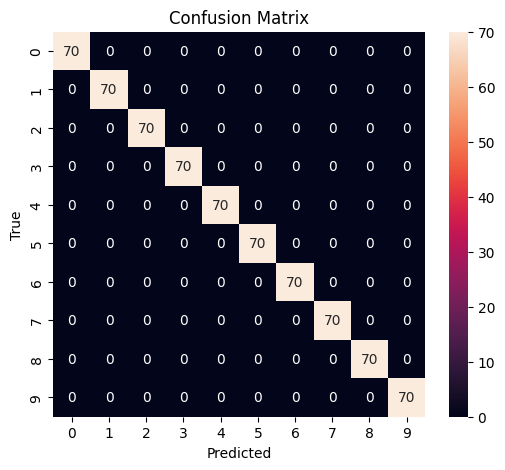

In [77]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(gt_labels, pr_labels)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

In [78]:
test_loss = []
gt_labels = []
pr_labels = []

with torch.no_grad():
    for inputs, labels in test_loader:

        inputs = inputs.to(device)
        labels = labels.to(device).long()

        outputs = alex_net(inputs)

        loss = criterion(outputs, labels)
        test_loss.append(loss.item())

        preds = torch.argmax(outputs, dim=1)

        gt_labels.append(labels.cpu().numpy())
        pr_labels.append(preds.cpu().numpy())

# combine
gt_labels = np.concatenate(gt_labels)
pr_labels = np.concatenate(pr_labels)

# accuracy
test_acc = (gt_labels == pr_labels).mean()

print(f"Test Loss: {np.mean(test_loss):.4f} | Test Accuracy: {test_acc:.3f}")

Test Loss: 0.3215 | Test Accuracy: 0.940


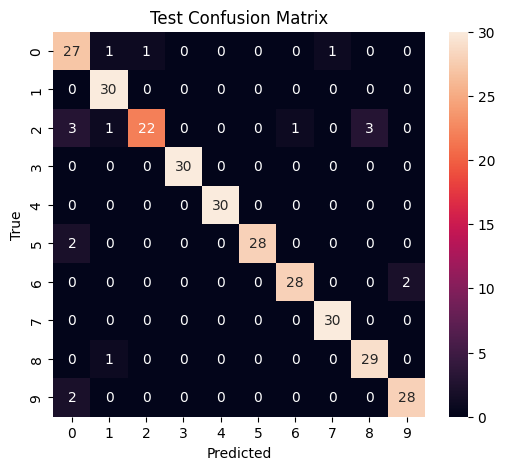

In [79]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(gt_labels, pr_labels)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Test Confusion Matrix")
plt.show()

**Tbles with models configurations and accuracies**

In [81]:
import pandas as pd

df = pd.DataFrame(results)
df

,model,lr,batch_size,dropout,frozen,img_size,val_loss,acc
0,AlexNet,0.000989,32,0.5,True,256,0.248978,0.915714
1,AlexNet,0.000957,32,0.5,True,256,0.056600,0.980000
2,AlexNet,0.000905,32,0.5,True,256,0.146697,0.938571
3,AlexNet,0.000836,32,0.5,True,256,0.049121,0.984286
4,AlexNet,0.000753,32,0.5,True,256,0.012949,0.997143
5,AlexNet,0.000658,32,0.5,True,256,0.002210,1.000000
6,AlexNet,0.000557,32,0.5,True,256,0.001105,1.000000
7,AlexNet,0.000453,32,0.5,True,256,0.001300,1.000000
8,AlexNet,0.000352,32,0.5,True,256,0.000769,1.000000
9,AlexNet,0.000258,32,0.5,True,256,0.000654,1.000000
